# Spiral in/out, and the instant three things have to share

[`../gre_spiral_2d/01_build.ipynb`](../gre_spiral_2d/01_build.ipynb) built the readout and every
number in it. A spin-echo spiral is **the same `Spiral2D` after a refocusing pulse**, which is the
whole argument for `readout/` being a leaf: the module holds no RF, knows nothing about slices, and
cannot tell a gradient echo from a spin echo.

What this directory exists for is one alignment:

> **the seam of the two arms, the `k = 0` sample, and the spin echo are the same instant.**

`variant='in-out'` is the readout that makes that possible. Its two arms meet at `k = 0`, where a
spiral's gradient is zero, so the join is exactly continuous with nothing between them — and `k = 0`
is therefore a *place in the middle of a continuous acquisition* rather than an end of it. Put that
place at the spin echo and the readout is symmetric in time about a T2 echo.

Two things follow, and both are measured below:

| | |
|---|---|
| **`prephase=False`** | the 2D dephaser moves to **before** the refocusing pulse, carrying the sign the conjugation will flip. It costs no echo time there, because the interval already exists — §4 prices what putting it after would cost |
| **TE is two numbers** | the gradient echo lands on the ADC raster and the spin echo on the gradient raster; they cannot be made equal, and the honest thing is to print the gap |

**Output:** four `.seq` files at one echo time — the reference in/out, a longer arm at two
interleaves, a variable-density taper, and the asymmetric `'out'` readout for
[`02`](02_simulate_and_reconstruct.ipynb) to measure against — plus a Cartesian reference and
`seq/se_spiral_2d_nominal.npz`. **Needs nothing but `seqcraft`.**


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc
from seqcraft.modules._support import oblique_trapezoid

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=180, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
    adc_samples_limit=8192,
)

FOV_MM = 220.0
MATRIX = 128
THICKNESS_MM = 3.0
DWELL_S = 2.5e-6
SHOTS = 4
VDS_DENSITY = (1.0, 0.5)
EXCITE_DURATION_S = 2.0e-3
REFOCUS_DURATION_S = 3.0e-3
REFOCUS_FACTOR = 1.25            # the 180 selects a thicker slab than the 90
CRUSH_CYCLES_SLICE = 4.0
SPOIL_CYCLES = 4.0
TE_S = 60.0e-3                   # one echo time for every file; section 2 finds the shortest
                                 # each can reach, and the two-shot arm is what sets this one
TR_S = 1.0
DUMMY_SHOTS = 1                  # a 90 leaves Mz = 0 whatever it started from, at this TR
REFERENCE_DTE_S = 2.46e-3
REFERENCE_BANDWIDTH_HZ_PX = 600.0
REFERENCE_FLIP_DEG = 15.0
REFERENCE_TR_S = 30.0e-3
REFERENCE_DUMMIES = 30

DK_PER_M = 1e3 / FOV_MM
KMAX_PER_M = MATRIX / (2 * FOV_MM * 1e-3)
grad_raster = sc.Raster(opts.grad_raster_time)
block_raster = sc.Raster(opts.block_duration_raster)

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)


def readout(**kwargs):
    """The spin-echo readout: two arms meeting at the origin, and the caller owes the dephaser."""
    base = dict(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, shots=SHOTS, dwell_s=DWELL_S,
                variant='in-out', prephase=False)
    return sc.modules.Spiral2D(**{**base, **kwargs})


def compiled(tree, name='probe', definitions=None):
    """Compile, dropping only the vector-norm warning every example here expects."""
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always', sc.SeqCraftWarning)
        seq = sc.compile(tree, opts, name=name, definitions=definitions)
    return seq, [str(w.message) for w in caught
                 if issubclass(w.category, sc.SeqCraftWarning)
                 and 'vector-norm' not in str(w.message)]


spiral = readout()
print(f'{spiral.variant}: {len(spiral.te_s)} echo, {spiral.readout_duration_s * 1e3:.3f} ms of '
      f'readout in {spiral.adc_segments} ADC events of {spiral.segment_samples} samples')
print(f'  the seam is at {spiral.time_to_echo(0) * 1e3:.4f} ms from the block start, and the '
      f'arms are {spiral.arm_duration_s * 1e3:.3f} ms each')
print(f'  |k| at the k = 0 sample: '
      f'{np.hypot(*spiral.k_per_m(shot=0)[:, spiral.echo_sample(0)]) / DK_PER_M:.4f} dk')
print()
print('prephase=False, so the module\'s block starts at the first arm and the caller owes it')
for shot in range(SHOTS):
    print(f'  shot {shot}: k_start_per_m = {np.round(spiral.k_start_per_m(shot), 2)} 1/m')
print('  A vector, one per interleaf -- which is the whole reason `oblique_trapezoid` exists.')


in-out: 1 echo, 26.860 ms of readout in 2 ADC events of (8192, 2384) samples
  the seam is at 13.2413 ms from the block start, and the arms are 13.230 ms each
  |k| at the k = 0 sample: 0.0209 dk

prephase=False, so the module's block starts at the first arm and the caller owes it
  shot 0: k_start_per_m = [ 2.9081e+02 -1.1000e-01] 1/m
  shot 1: k_start_per_m = [1.1000e-01 2.9081e+02] 1/m
  shot 2: k_start_per_m = [-2.9081e+02  1.1000e-01] 1/m
  shot 3: k_start_per_m = [-1.1000e-01 -2.9081e+02] 1/m
  A vector, one per interleaf -- which is the whole reason `oblique_trapezoid` exists.


---
## 1. The dephaser is one oblique trapezoid, not two

A refocusing pulse maps `k` to `−k`, so a dephaser placed **before** it carries the opposite sign
of the one that would follow it: the caller lays down `−k_start_per_m(shot)` and the conjugation
turns it into `+k_start_per_m(shot)`.

That is `EPI2D`'s `prephase=False` story with a **vector** in place of a scalar, and the vector is
what changes. A gradient amplifier's limit on a 2D gradient is on the *vector* slew, and two
trapezoids designed independently and stretched to a common duration each reach `max_slew` and
together ask for `sqrt(2)` times it. `check_limits` measures the summed waveform per axis and does
not see it — so it is reported as the same `slew_norm` warning that three spoiler axes produce,
which is exactly the wrong report for a dephaser that *is* one oblique vector.


In [2]:
print(f'{"":22s} {"duration":>9s} {"vector peak":>12s} {"vector slew":>12s}   at')
for angle_deg in (0.0, 45.0, 57.3):
    angle = np.deg2rad(angle_deg)
    area = KMAX_PER_M * np.array([np.cos(angle), np.sin(angle)])
    per_axis = [pp.make_trapezoid(axis, area=component, system=opts)
                for axis, component in zip('xy', area)]
    window = max(float(pp.calc_duration(g)) for g in per_axis)
    per_axis = [pp.make_trapezoid(axis, area=component, duration=window, system=opts)
                for axis, component in zip('xy', area)]
    for label, pair in (('two trapezoids', per_axis),
                        ('oblique_trapezoid', oblique_trapezoid(area_per_m=area, opts=opts))):
        peak = np.hypot(*[float(g.amplitude) for g in pair])
        print(f'{label:22s} {pp.calc_duration(*pair) * 1e6:8.1f}u '
              f'{peak / opts.gamma * 1e3:11.2f} '
              f'{peak / float(pair[0].rise_time) / opts.gamma:11.2f}   {angle_deg:.1f} deg')
print(f'  against a {opts.max_slew / opts.gamma:.0f} T/m/s amplifier.  One trapezoid of area')
print('  hypot(ax, ay), split across the two axes by direction cosines, has the same timing and')
print('  the same vector peak at every angle -- which a per-axis pair does not.')


                        duration  vector peak  vector slew   at
two trapezoids            400.0u       28.47      177.93   0.0 deg
oblique_trapezoid         400.0u       28.47      177.93   0.0 deg
two trapezoids            340.0u       32.54      250.28   45.0 deg
oblique_trapezoid         400.0u       28.47      177.93   45.0 deg
two trapezoids            360.0u       31.63      395.34   57.3 deg
oblique_trapezoid         400.0u       28.47      177.93   57.3 deg
  against a 180 T/m/s amplifier.  One trapezoid of area
  hypot(ax, ay), split across the two axes by direction cosines, has the same timing and
  the same vector peak at every angle -- which a per-axis pair does not.


## 2. `SESpiral2D`, and TE as two numbers

Everything except the dephaser is a refocusing pulse dropped into an interval that was already
there.

| | |
|---|---|
| **TE is symmetric about the refocusing centre** | so the shortest one is **twice** the longer of the two halves: excitation centre → pulse centre, and pulse centre → the seam |
| **the pulse is placed with `Raster.nearest`, not `ceil`** | the residual is *doubled* on its way to the spin echo, so rounding one way costs twice what it looks like |
| **the crusher pair is `Refocusing`'s own** | both crushers straddle its own pulse, so it balances them itself. The dephaser before it is not a crusher and is not its business |

`Refocusing` selects a slab 1.25× the excitation's, for [`../se_2d/`](../se_2d/01_build.ipynb)'s
reason: a refocusing profile's edges are worse than an excitation's, and a slice refocused only in
its middle loses its edges twice per echo.


In [3]:
class SESpiral2D(sc.Module):
    """A spin-echo spiral.  One difference from the gradient echo, and it is a placement."""

    def __init__(self, *, opts, fov_mm, matrix, thickness_mm, flip_deg=90.0,
                 refocus_flip_deg=180.0, te_s=None, tr_s=None, excitation_duration_s=2.0e-3,
                 refocus_duration_s=3.0e-3, refocus_thickness_factor=1.25,
                 crush_cycles_slice=4.0, spoil_cycles_per_voxel=4.0, align='seam', tag=None,
                 **spiral_kwargs):
        super().__init__(opts=opts, tag=tag)
        self.raster = sc.Raster(opts.grad_raster_time)
        self.block_raster = sc.Raster(opts.block_duration_raster)
        self.thickness_mm = float(thickness_mm)
        self.align = align

        self.exc = sc.modules.Excitation(opts=opts, flip_deg=flip_deg,
                                         thickness_mm=self.thickness_mm,
                                         duration_s=excitation_duration_s)
        self.refoc = sc.modules.Refocusing(
            opts=opts, thickness_mm=self.thickness_mm * refocus_thickness_factor,
            flip_deg=refocus_flip_deg, duration_s=refocus_duration_s,
            crush_cycles_per_voxel=crush_cycles_slice, crush_voxel_mm=self.thickness_mm)
        self.spiral = sc.modules.Spiral2D(opts=opts, fov_mm=fov_mm, matrix=matrix,
                                          **spiral_kwargs)

        # The dephaser window: one oblique trapezoid, designed at the largest |k_start| any
        # interleaf asks for -- which is the same for all of them, because rotating a vector does
        # not change its length -- and running beside the slice rephaser rather than after it.
        self.k_start_per_m = float(np.hypot(*self.spiral.k_start_per_m(0)))
        self.deph_s = float(self.raster.ceil(max(
            float(pp.calc_duration(*oblique_trapezoid(
                area_per_m=(self.k_start_per_m, 0.0), opts=opts))) if self.k_start_per_m else 0.0,
            self.exc.rephaser_duration_s)))
        self._deph_start_s = float(self.raster.ceil(
            max(self.exc.time_to_rephaser(), float(pp.calc_duration(self.exc.rf)))))

        # TE is symmetric about the refocusing centre, so the minimum is twice the longer half.
        self.min_te_s = 2 * float(self.raster.ceil(max(
            self._deph_start_s + self.deph_s + self.refoc.time_to_center()
            - self.exc.time_to_center(),
            self.refoc().duration - self.refoc.time_to_center() + self._readout_offset_s)))
        target_te_s = self.min_te_s + fill_s(self.raster, te_s, self.min_te_s)
        self._readout_start_s = float(self.raster.ceil(
            self.exc.time_to_center() + target_te_s - self._readout_offset_s))
        #: The **gradient** echo: when the k = 0 sample is actually taken, from the excitation.
        self.te_s = (self._readout_start_s + self.spiral.time_to_echo(0)
                     - self.exc.time_to_center())
        # Nearest, not ceil: the residual is doubled on its way to the spin echo.
        self._refoc_start_s = float(self.raster.nearest(
            self.exc.time_to_center() + target_te_s / 2 - self.refoc.time_to_center()))
        #: The **spin** echo: twice the excitation-centre-to-pulse-centre interval.
        self.spin_echo_s = 2 * (self._refoc_start_s + self.refoc.time_to_center()
                                - self.exc.time_to_center())

        voxel_mm = {'x': fov_mm / matrix, 'y': fov_mm / matrix, 'z': self.thickness_mm}
        self.spoil_area = {axis: spoil_cycles_per_voxel / (voxel_mm[axis] / 1e3)
                           for axis in ('x', 'y', 'z')}
        self.tail_s = float(self.raster.ceil(max(
            float(pp.calc_duration(pp.make_trapezoid(axis, area=area, system=opts)))
            for axis, area in self.spoil_area.items())))
        self.shot_s = (self._readout_start_s + self.spiral.readout_duration_s + self.tail_s)
        self.tr_s = tr_of(self.block_raster, tr_s, self.shot_s)

    @property
    def _readout_offset_s(self):
        """What inside the readout block the echo time is placed against.

        ``'seam'`` is the ``k = 0`` sample, which is the whole point of the directory.  ``'first'``
        is the readout's *first* sample, which is the version built wrong in section 3 -- it
        compiles, every k is right, and the contrast is not the one asked for.
        """
        return (self.spiral.time_to_echo(0) if self.align == 'seam'
                else float(self.spiral.t_adc_s[0]))

    @property
    def min_tr_s(self):
        return float(self.block_raster.ceil(self.shot_s))

    def build(self, *, shot=None, angle_rad=None, acquire=True, segment=None, reference=None):
        # Excite about +y and refocus about +x: ninety degrees apart is the fixed point of the map
        # a refocusing pulse applies to transverse phase, and the receiver then stays at 0.
        out = sc.LogicBlock().add([[0.0, self.exc(phase_deg=90.0)],
                                   [self._refoc_start_s, self.refoc(phase_deg=0.0)]])
        if self.k_start_per_m:
            # Minus, because the pulse conjugates it: what is laid down here comes back with the
            # opposite sign, and `k_start_per_m` is what the readout needs to find when it starts.
            wanted = -self.spiral.k_start_per_m(shot=shot, angle_rad=angle_rad)
            out.add(self._deph_start_s,
                    *oblique_trapezoid(area_per_m=wanted, opts=self.opts,
                                       duration_s=self.deph_s))
        out.add(self._readout_start_s,
                self.spiral(shot=shot, angle_rad=angle_rad, acquire=acquire, segment=segment,
                            reference=reference))
        for axis, area in self.spoil_area.items():
            out.add(self._readout_start_s + self.spiral.readout_duration_s,
                    pp.make_trapezoid(axis, area=area, duration=self.tail_s, system=self.opts))
        fill = float(self.block_raster.ceil(self.tr_s - self.shot_s))
        if fill > 1e-9:
            out.add(self.shot_s, pp.make_delay(fill))
        return out


def fill_s(raster, wanted, floor_s):
    """How much dead time a requested TE needs beyond the shortest one this shot can reach."""
    if wanted is None:
        return 0.0
    if float(wanted) < floor_s - 1e-12:
        raise sc.ConfigurationError(
            f'te_s = {float(wanted) * 1e3:.3f} ms is shorter than the {floor_s * 1e3:.3f} ms this '
            f'shot can achieve.')
    return float(raster.ceil(float(wanted) - floor_s))


def tr_of(block_raster, wanted, shot_s):
    if wanted is None:
        return float(block_raster.ceil(shot_s))
    if float(wanted) < float(block_raster.ceil(shot_s)) - 1e-12:
        raise sc.ConfigurationError(
            f'tr_s = {float(wanted) * 1e3:.3f} ms is shorter than the '
            f'{block_raster.ceil(shot_s) * 1e3:.3f} ms one shot occupies.')
    return float(block_raster.ceil(float(wanted)))


def kernel_for(**overrides):
    """One `SESpiral2D` at the reference protocol, with whatever this cell is varying."""
    base = dict(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                te_s=TE_S, tr_s=TR_S, excitation_duration_s=EXCITE_DURATION_S,
                refocus_duration_s=REFOCUS_DURATION_S,
                refocus_thickness_factor=REFOCUS_FACTOR,
                crush_cycles_slice=CRUSH_CYCLES_SLICE,
                spoil_cycles_per_voxel=SPOIL_CYCLES,
                shots=SHOTS, dwell_s=DWELL_S, variant='in-out', prephase=False)
    return SESpiral2D(**{**base, **overrides})


kernel = kernel_for()
print(f'dephaser window {kernel.deph_s * 1e6:.0f} us, beside the {kernel.exc.rephaser_duration_s * 1e6:.0f} us slice rephaser')
print(f'min TE {kernel.min_te_s * 1e3:.3f} ms, asked {TE_S * 1e3:.1f} ms')
print(f'gradient echo {kernel.te_s * 1e3:.4f} ms')
print(f'spin echo     {kernel.spin_echo_s * 1e3:.4f} ms')
print(f'the gap between them {abs(kernel.te_s - kernel.spin_echo_s) * 1e6:.2f} us = '
      f'{abs(kernel.te_s - kernel.spin_echo_s) / DWELL_S:.2f} dwells')
print(f'shot {kernel.shot_s * 1e3:.2f} ms, TR {kernel.tr_s * 1e3:.0f} ms')
print()
print('Two numbers because they live on different rasters: the ADC sample is a half-dwell offset')
print('into a window that starts on the gradient raster, and the pulse centre is on the gradient')
print('raster too -- so the two can be brought within a dwell of each other and no closer.')


dephaser window 640 us, beside the 640 us slice rephaser
min TE 31.740 ms, asked 60.0 ms
gradient echo 60.0013 ms
spin echo     60.0000 ms
the gap between them 1.25 us = 0.50 dwells
shot 76.32 ms, TR 1000 ms

Two numbers because they live on different rasters: the ADC sample is a half-dwell offset
into a window that starts on the gradient raster, and the pulse centre is on the gradient
raster too -- so the two can be brought within a dwell of each other and no closer.


## 3. The alignment, and the same sequence built wrong

The readout is placed against **`time_to_echo(0)`** — its `k = 0` sample. The plausible mistake is
to place it against its *start*, which for a spiral-out would be the same thing and for a spiral
in/out is a whole arm away.

That version compiles. Every `k` in it is correct. The trajectory is the same trajectory. What
moves is **when the centre of k-space is acquired relative to the spin echo**, and the image then
carries T2\* decay with a refocusing pulse sitting uselessly in the middle of it.


In [4]:
wrong = kernel_for(align='first')
print(f'{"placed against":16s} {"gradient echo":>14s} {"spin echo":>11s} {"k = 0 minus spin echo":>22s}')
for label, made in (('the seam', kernel), ('the first sample', wrong)):
    print(f'{label:16s} {made.te_s * 1e3:13.4f}m {made.spin_echo_s * 1e3:10.4f}m '
          f'{(made.te_s - made.spin_echo_s) * 1e3:21.4f}m')
print(f'  One arm is {kernel.spiral.arm_duration_s * 1e3:.3f} ms, and that is exactly the '
      f'displacement.')
print()

# Both, through sc.kspace -- the only oracle here that models the conjugation the 180 applies.
for label, made in (('the seam', kernel), ('the first sample', wrong)):
    tree = sc.LogicBlock('shot').add(0.0, made(shot=1))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        k = sc.kspace(tree, opts)
    seq, notes = compiled(tree)
    echo = made.spiral.echo_sample(0)
    measured = float(k['t_adc'][echo] - k['t_excitation'][0])
    print(f'{label:16s} |k| at the k = 0 sample '
          f'{np.hypot(*k["k_adc"][:2, echo]) / DK_PER_M:7.4f} dk, taken at '
          f'{measured * 1e3:.4f} ms  ({abs(measured - made.te_s) * 1e9:.0f} ns from the reported '
          f'TE)')
    print(f'{"":16s} the readout leaves |k| = '
          f'{np.hypot(*made.spiral.k_end_per_m(1)):.2e} 1/m behind it, so what the spoiler winds '
          f'is its own' + (f'   warnings {notes}' if notes else ''))
print()
print('Both are correct sequences.  The dephaser sign is right in both -- |k| at the k = 0 sample')
print('is a fiftieth of a dk, which it would not be if the conjugation had flipped a sign the')
print('caller did not intend -- and the readout rewinds itself, so the spoiler that follows')
print("winds its own cycles and not the arm's leftovers.  The difference between the rows")
print('is entirely in *when* that sample is taken, and nothing in the file says which was meant.')


placed against    gradient echo   spin echo  k = 0 minus spin echo
the seam               60.0013m    60.0000m                0.0013m
the first sample       73.2313m    60.0000m               13.2312m
  One arm is 13.230 ms, and that is exactly the displacement.

the seam         |k| at the k = 0 sample  0.0209 dk, taken at 60.0013 ms  (0 ns from the reported TE)
                 the readout leaves |k| = 0.00e+00 1/m behind it, so what the spoiler winds is its own


the first sample |k| at the k = 0 sample  0.0209 dk, taken at 73.2313 ms  (0 ns from the reported TE)
                 the readout leaves |k| = 0.00e+00 1/m behind it, so what the spoiler winds is its own

Both are correct sequences.  The dephaser sign is right in both -- |k| at the k = 0 sample
is a fiftieth of a dk, which it would not be if the conjugation had flipped a sign the
caller did not intend -- and the readout rewinds itself, so the spoiler that follows
winds its own cycles and not the arm's leftovers.  The difference between the rows
is entirely in *when* that sample is taken, and nothing in the file says which was meant.


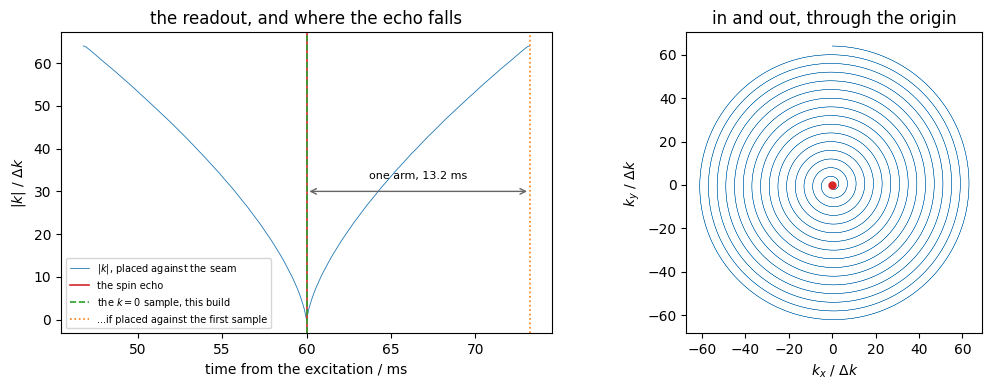

In [5]:
tree = sc.LogicBlock('shot').add(0.0, kernel(shot=1))
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    k = sc.kspace(tree, opts)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
t_ms = (k['t_adc'] - float(k['t_excitation'][0])) * 1e3
axes[0].plot(t_ms, np.hypot(*k['k_adc'][:2]) / DK_PER_M, lw=0.6, color='C0',
             label='$|k|$, placed against the seam')
axes[0].axvline(kernel.spin_echo_s * 1e3, color='C3', lw=1.2, label='the spin echo')
axes[0].axvline(kernel.te_s * 1e3, color='C2', lw=1.2, ls='--',
                label='the $k=0$ sample, this build')
axes[0].axvline(wrong.te_s * 1e3, color='C1', lw=1.2, ls=':',
                label='...if placed against the first sample')
axes[0].annotate('', xy=(wrong.te_s * 1e3, 30), xytext=(kernel.te_s * 1e3, 30),
                 arrowprops={'arrowstyle': '<->', 'color': '0.4'})
axes[0].text(0.5 * (wrong.te_s + kernel.te_s) * 1e3, 33,
             f'one arm, {kernel.spiral.arm_duration_s * 1e3:.1f} ms', ha='center', fontsize=8)
axes[0].set(xlabel='time from the excitation / ms', ylabel='$|k|$ / $\\Delta k$',
            title='the readout, and where the echo falls')
axes[0].legend(fontsize=7)

axes[1].plot(k['k_adc'][0] / DK_PER_M, k['k_adc'][1] / DK_PER_M, lw=0.3)
axes[1].plot(*(k['k_adc'][:2, kernel.spiral.echo_sample(0)] / DK_PER_M), 'o', ms=5, color='C3')
axes[1].set(xlabel='$k_x$ / $\\Delta k$', ylabel='$k_y$ / $\\Delta k$', aspect='equal',
            title='in and out, through the origin')
fig.tight_layout()


## 4. What `prephase=True` would cost

Putting the dephaser **after** the pulse is legal and it costs echo time twice: once for the ramp
itself, and once again because the interval before the pulse has to grow to match — TE is
symmetric about the refocusing centre.


In [6]:
before = kernel_for()
after = SESpiral2D(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, thickness_mm=THICKNESS_MM,
                   te_s=None, tr_s=TR_S, excitation_duration_s=EXCITE_DURATION_S,
                   refocus_duration_s=REFOCUS_DURATION_S,
                   refocus_thickness_factor=REFOCUS_FACTOR,
                   crush_cycles_slice=CRUSH_CYCLES_SLICE, spoil_cycles_per_voxel=SPOIL_CYCLES,
                   shots=SHOTS, dwell_s=DWELL_S, variant='in-out')     # prephase inside the arm
minimum_before = kernel_for(te_s=None)
print(f'{"the dephaser":26s} {"in the readout":>15s} {"min TE":>9s} {"readout":>9s}')
print(f'{"before the 180":26s} {"no":>15s} {minimum_before.min_te_s * 1e3:8.3f}m '
      f'{minimum_before.spiral.readout_duration_s * 1e3:8.3f}m')
print(f'{"after it, inside the arm":26s} {"yes":>15s} {after.min_te_s * 1e3:8.3f}m '
      f'{after.spiral.readout_duration_s * 1e3:8.3f}m')
print(f'  {(after.min_te_s - minimum_before.min_te_s) * 1e6:.0f} us of echo time, for a ramp of '
      f'{(after.spiral.readout_duration_s - minimum_before.spiral.readout_duration_s) * 1e6:.0f} '
      f'us --')
print('  twice, because the interval before the pulse has to grow to match it.  Before the pulse')
print('  the same ramp costs nothing at all: the interval is already there and it was empty.')


the dephaser                in the readout    min TE   readout
before the 180                          no   31.740m   26.860m
after it, inside the arm               yes   32.480m   27.240m
  740 us of echo time, for a ramp of 380 us --
  twice, because the interval before the pulse has to grow to match it.  Before the pulse
  the same ramp costs nothing at all: the interval is already there and it was empty.


## 5. `'in-out'` against `'out'`, at the same echo time

The same spin echo, the same arm, the same `kmax` — and a different arrangement of them in time.
An `'out'` readout starts at `k = 0`, so it needs no dephaser at all and its sampling is entirely
*after* the echo; an `'in-out'` readout is symmetric about it.

That symmetry is the reason spiral in/out is the BOLD readout, and it is not a timing nicety: the
linear-in-time part of the off-resonance phase is **antisymmetric across the readout**, so its
point spread stays close to real. [`02`](02_simulate_and_reconstruct.ipynb) measures that on a
point object; here it is only the arrangement.


In [7]:
print(f'{"variant":10s} {"dephaser":>9s} {"readout":>9s} {"min TE":>9s} {"TE":>9s} '
      f'{"sampling around the echo":>26s}')
for variant in ('in-out', 'out'):
    made = kernel_for(variant=variant, prephase=False if variant == 'in-out' else None)
    before_s = made.spiral.time_to_echo(0) - float(made.spiral.t_adc_s[0])
    after_s = float(made.spiral.t_adc_s[-1]) - made.spiral.time_to_echo(0)
    print(f'{variant:10s} {made.k_start_per_m:8.1f} {made.spiral.readout_duration_s * 1e3:8.3f}m '
          f'{made.min_te_s * 1e3:8.3f}m {made.te_s * 1e3:8.3f}m '
          f'{f"-{before_s * 1e3:.2f} .. +{after_s * 1e3:.2f} ms":>26s}')
print('  The dephaser column is |k_start| in 1/m: an `out` readout owes nothing, because it')
print('  begins where the pulse leaves k.  It also pays for that -- everything it samples is')
print('  after the echo, so its off-resonance phase is one-sided and its blur is complex.')


variant     dephaser   readout    min TE        TE   sampling around the echo
in-out        290.8   26.860m   31.740m   60.001m        -13.23 .. +13.23 ms


out             0.0   13.630m    8.700m   60.001m         -0.00 .. +13.23 ms
  The dephaser column is |k_start| in 1/m: an `out` readout owes nothing, because it
  begins where the pulse leaves k.  It also pays for that -- everything it samples is
  after the echo, so its off-resonance phase is one-sided and its blur is complex.


---
## The files

Four `.seq` files **all at one echo time**, so a difference between two pictures in
[`02`](02_simulate_and_reconstruct.ipynb) is the acquisition being compared rather than its
contrast. Plus the same dual-echo Cartesian reference `../gre_spiral_2d/01` writes — the B0 map and
the coil sensitivities a spiral reconstruction needs cannot come from a spiral, because
reconstructing the spiral is what needs them.


In [8]:
def write(name, made, *, dummy_shots=DUMMY_SHOTS):
    """Write one acquisition: every interleaf in order, after a run-in."""
    order = list(range(made.spiral.shots))
    tree = sc.LogicBlock(name)
    played = [order[0]] * dummy_shots + order
    for n, interleaf in enumerate(played):
        acquire = n >= dummy_shots
        tree.add(n * made.tr_s, made(shot=interleaf, acquire=acquire,
                                     segment=(n - dummy_shots) if acquire else None))
    seq, notes = compiled(tree, name, {
        'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
        'SliceThickness': THICKNESS_MM / 1e3,
        'TE': made.te_s, 'TR': made.tr_s,
        'ReceiverBandwidth': made.spiral.bandwidth_hz,
    })
    seq.write(str(SEQ_DIR / f'{name}.seq'))
    print(f'-> {name + ".seq":30s} {len(seq.block_events):5d} blocks  '
          f'{seq.duration()[0]:7.2f} s  {len(order)} interleaf(s), TE {made.te_s * 1e3:.4f} ms, '
          f'spin echo {made.spin_echo_s * 1e3:.4f} ms'
          + (f'  WARNINGS {notes}' if notes else ''))
    return made


built = {
    'se_spiral_inout_4shot': write('se_spiral_inout_4shot', kernel),
    'se_spiral_inout_2shot': write('se_spiral_inout_2shot', kernel_for(shots=2)),
    'se_spiral_inout_vds': write('se_spiral_inout_vds', kernel_for(density=VDS_DENSITY)),
    'se_spiral_out_4shot': write('se_spiral_out_4shot',
                                 kernel_for(variant='out', prephase=None)),
}

reference = sc.modules.GRE2D(
    opts=opts, fov_mm=(FOV_MM, FOV_MM), matrix=(MATRIX, MATRIX), thickness_mm=THICKNESS_MM,
    flip_deg=REFERENCE_FLIP_DEG, echoes=2, polarity='monopolar',
    bandwidth_hz_px=REFERENCE_BANDWIDTH_HZ_PX, echo_spacing_s=REFERENCE_DTE_S,
    tr_s=REFERENCE_TR_S, rf_spoil_deg=117.0)
echo_times = np.array(reference.tr.ro.te_s)
delta_te_s = float(np.diff(echo_times)[0])
ref_tree = sc.LogicBlock('se_spiral_reference')
ref_tree.add(0.0, reference(lines=range(MATRIX), dummies=REFERENCE_DUMMIES))
ref_seq, _ = compiled(ref_tree, 'se_spiral_reference', {
    'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
    'SliceThickness': THICKNESS_MM / 1e3, 'TE': reference.tr.te_s, 'TR': REFERENCE_TR_S})
ref_seq.write(str(SEQ_DIR / 'se_spiral_reference.seq'))
print(f'-> {"se_spiral_reference.seq":30s} {len(ref_seq.block_events):5d} blocks  '
      f'{ref_seq.duration()[0]:7.2f} s  dual-echo Cartesian, dTE {delta_te_s * 1e6:.0f} us')

spread = np.ptp([made.te_s for made in built.values()])
print(f'\nrequested TE {TE_S * 1e3:.1f} ms, spread across the four files {spread * 1e6:.2f} us '
      f'= {spread / opts.grad_raster_time:.2f} gradient rasters')
assert spread <= opts.grad_raster_time + 1e-12


-> se_spiral_inout_4shot.seq         44 blocks     5.00 s  4 interleaf(s), TE 60.0013 ms, spin echo 60.0000 ms


-> se_spiral_inout_2shot.seq         28 blocks     3.00 s  2 interleaf(s), TE 60.0088 ms, spin echo 60.0000 ms


-> se_spiral_inout_vds.seq           40 blocks     5.00 s  4 interleaf(s), TE 60.0088 ms, spin echo 60.0000 ms
-> se_spiral_out_4shot.seq           40 blocks     5.00 s  4 interleaf(s), TE 60.0012 ms, spin echo 60.0000 ms


-> se_spiral_reference.seq         1106 blocks     4.74 s  dual-echo Cartesian, dTE 2460 us

requested TE 60.0 ms, spread across the four files 7.50 us = 0.75 gradient rasters


In [9]:
u = np.linspace(0.0, 1.0, 64)
payload = {}
for name, made in built.items():
    rows = []
    for interleaf in range(made.spiral.shots):
        tree = sc.LogicBlock('one').add(0.0, made(shot=interleaf))
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            measured = sc.kspace(tree, opts)['k_adc'][:2]
        assert np.abs(measured - made.spiral.k_per_m(shot=interleaf)).max() < 1e-4, name
        rows.append(measured)
    payload[f'{name}_k_per_m'] = np.stack(rows).astype(np.float32)
    payload[f'{name}_t_adc_s'] = made.spiral.t_adc_s
    payload[f'{name}_te_s'] = np.array(made.spiral.te_s)
    payload[f'{name}_te_from_excitation_s'] = np.array([made.te_s])
    payload[f'{name}_spin_echo_s'] = made.spin_echo_s
    payload[f'{name}_fov_mm_of_kr'] = np.stack([u, made.spiral.fov_mm_of(u)])
    payload[f'{name}_shots'] = made.spiral.shots

np.savez(
    SEQ_DIR / 'se_spiral_2d_nominal.npz',
    matrix=MATRIX, fov_mm=FOV_MM, thickness_mm=THICKNESS_MM, dwell_s=DWELL_S,
    te_s=TE_S, tr_s=TR_S, dummy_shots=DUMMY_SHOTS, vds_density=np.array(VDS_DENSITY),
    reference_delta_te_s=delta_te_s, reference_te_s=echo_times,
    reference_te1_s=reference.tr.te_s, reference_tr_s=REFERENCE_TR_S,
    reference_flip_deg=REFERENCE_FLIP_DEG, reference_dummies=REFERENCE_DUMMIES,
    reference_bandwidth_hz_px=REFERENCE_BANDWIDTH_HZ_PX, reference_lines=np.arange(MATRIX),
    **payload,
)
print(f'-> {SEQ_DIR / "se_spiral_2d_nominal.npz"}')
print('   Every trajectory read back off the compiled file and asserted against the module, and')
print('   the echo times written next to them -- which is the number `02` corrects against.')


-> seq\se_spiral_2d_nominal.npz
   Every trajectory read back off the compiled file and asserted against the module, and
   the echo times written next to them -- which is the number `02` corrects against.


---
## What this notebook established

| | |
|---|---|
| **the seam, the `k = 0` sample and the spin echo are one instant** | to within a dwell, which is as close as two different rasters allow |
| **`prephase=False` puts the dephaser before the pulse** | with the sign the conjugation flips, where it costs no echo time — and putting it after would cost twice its own length |
| **the dephaser is one oblique trapezoid** | same duration and same vector peak at every interleaf angle, where two independent trapezoids reach `sqrt(2)·max_slew` and compile cleanly |
| **the wrong alignment compiles** | every `k` correct, every waveform legal, and the centre of k-space acquired a whole arm from the spin echo — which is T2\* contrast with a 180 in it |
| **an `'out'` readout needs no dephaser** | and pays for it in symmetry: everything it samples is after the echo |

What none of it can say is whether the echo is a **T2** echo, and what the blur actually looks
like. [`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) measures both.
